# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laspric/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research Question

Which content pages should be prioritized for review or refresh based on their search performance signals?

### Decision Supported

This analysis will help content teams identify and prioritize pages that may deserve review, refresh, improvement, or monitoring.

## 2. Data

### Data Source

This project will use the FlyRank ML Internship full warehouse release.

### Data Selection

I will select the tables and fields needed to study content refresh opportunities and search performance.

### Exclusions

Client-identifying information, private queries, credentials, raw exports, and label-derived or future-looking fields that could cause data leakage will be excluded from the modeling features.

### Public Safety

The analysis will use only safe, aggregated or pseudonymous data and will not disclose client names, domains, private queries, or confidential information.

In [1]:
!git clone https://github.com/Laspric/flyrank-internship-ml.git
%cd /content/flyrank-internship-ml

Cloning into 'flyrank-internship-ml'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 155 (delta 60), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 1.88 MiB | 11.72 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/flyrank-internship-ml


In [2]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset shape: (30000, 44)
Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [3]:
# Columns that may contain the outcome/label
print("Potential label/leakage columns:")
print([
    "trend_direction",
    "trend_pct"
])

print("\nTheir values:")
print(df[["trend_direction", "trend_pct"]].head())

Potential label/leakage columns:
['trend_direction', 'trend_pct']

Their values:
  trend_direction  trend_pct
0            down      -41.4
1            down      -57.7
2            down      -60.9
3          stable      -13.8
4            down      -34.7


In [4]:
print("Potential label/leakage columns:")
print([
    "trend_direction",
    "trend_pct"
])

print("\nTheir values:")
print(df[["trend_direction", "trend_pct"]].head())

Potential label/leakage columns:
['trend_direction', 'trend_pct']

Their values:
  trend_direction  trend_pct
0            down      -41.4
1            down      -57.7
2            down      -60.9
3          stable      -13.8
4            down      -34.7


In [5]:
# Step 10 — Group the dataset columns

id_columns = [
    "content_id",
    "client_id"
]

possible_leakage = [
    "trend_direction",
    "trend_pct"
]

print("ID / grouping columns:")
print(id_columns)

print("\nPossible target / leakage columns:")
print(possible_leakage)

print("\nAll remaining columns:")
remaining_columns = [
    col for col in df.columns
    if col not in id_columns + possible_leakage
]

print(remaining_columns)
print("\nNumber of remaining columns:", len(remaining_columns))

ID / grouping columns:
['content_id', 'client_id']

Possible target / leakage columns:
['trend_direction', 'trend_pct']

All remaining columns:
['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier']

Number of remaining columns: 40


In [6]:
# Step 11 — Inspect candidate features

candidate_columns = [
    col for col in df.columns
    if col not in ["content_id", "client_id", "trend_direction", "trend_pct"]
]

feature_info = pd.DataFrame({
    "column": candidate_columns,
    "dtype": [df[col].dtype for col in candidate_columns],
    "missing": [df[col].isna().sum() for col in candidate_columns],
    "unique_values": [df[col].nunique() for col in candidate_columns]
})

print(feature_info.to_string(index=False))

                column   dtype  missing  unique_values
         search_volume float64     2468             41
           competition float64     2468            101
     competition_level  object     2610              3
                   cpc float64     2468            915
          content_type  object        0              3
           main_intent  object     2374              4
            word_count float64     7699           5476
            char_count float64     7699          14839
         provider_used  object    21438              2
            model_used  object     5733              5
       impressions_90d   int64        0           9438
            clicks_90d   int64        0            477
         pageviews_90d   int64        0            856
          sessions_90d   int64        0            666
             users_90d   int64        0            644
  engaged_sessions_90d   int64        0             68
       ai_sessions_90d   int64        0             35
     scrol

In [7]:
# Step 12 — Create the target

df["declining_target"] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target distribution:")
print(df["declining_target"].value_counts())

print("\nTarget proportions:")
print(df["declining_target"].value_counts(normalize=True))

Target distribution:
declining_target
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
declining_target
1    0.542067
0    0.457933
Name: proportion, dtype: float64


In [8]:
# Step 13 — Define the model features

features = [
    "search_volume",
    "competition",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

print("Number of features:", len(features))
print("\nFeatures:")
print(features)

Number of features: 30

Features:
['search_volume', 'competition', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']


In [9]:
# Step 14 — Check missing values in selected features

missing = df[features].isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print("Features with missing values:")
print(missing)

print("\nTotal missing values:", df[features].isna().sum().sum())

Features with missing values:
word_count       7699
char_count       7699
search_volume    2468
cpc              2468
competition      2468
main_intent      2374
scroll_rate       125
dtype: int64

Total missing values: 25301


In [10]:
# Step 15 — Identify numeric and categorical features

numeric_features = df[features].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df[features].select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 28
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct']

Categorical features: 2
['content_type', 'main_intent']


In [11]:
# Step 16 — Create training and test sets

from sklearn.model_selection import train_test_split

X = df[features]
y = df["declining_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining decline rate:", y_train.mean())
print("Test decline rate:", y_test.mean())

Training rows: 24000
Test rows: 6000

Training decline rate: 0.5420833333333334
Test decline rate: 0.542


In [12]:
# Step 17 — Build preprocessing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessing pipeline created.
Numeric features: 28
Categorical features: 2


In [13]:
# Step 18 — Train Logistic Regression model

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [14]:
# Cell 1 — Load data and create target

import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Create the target:
# 1 = declining, 0 = not declining
df["declining_target"] = (df["trend_direction"] == "down").astype(int)

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["declining_target"].value_counts())

print("\nTarget proportions:")
print(df["declining_target"].value_counts(normalize=True))

Dataset shape: (30000, 45)

Target distribution:
declining_target
1    16262
0    13738
Name: count, dtype: int64

Target proportions:
declining_target
1    0.542067
0    0.457933
Name: proportion, dtype: float64


In [15]:
# Cell 2 — Define features and train/test split

from sklearn.model_selection import train_test_split

features = [
    "search_volume",
    "competition",
    "cpc",
    "content_type",
    "main_intent",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[features]
y = df["declining_target"]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Features:", len(features))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training decline rate:", y_train.mean())
print("Test decline rate:", y_test.mean())

Features: 30
Numeric features: 28
Categorical features: 2
Training rows: 24000
Test rows: 6000
Training decline rate: 0.5420833333333334
Test decline rate: 0.542


In [17]:
# Cell 3 — Preprocessing and Logistic Regression

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Full model pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [18]:
# Step 19 — Predictions and evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Class predictions
y_pred = model.predict(X_test)

# Probability of being declining
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Model Results")
print("----------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\nBase rate:")
print(f"{y_test.mean():.4f}")

Model Results
----------------
Accuracy : 0.8212
Precision: 0.8339
Recall   : 0.8367
F1 Score : 0.8353
ROC-AUC  : 0.9146

Base rate:
0.5420


In [19]:
# Step 21 — Build the baseline rule

# Simple baseline:
# Flag a page as declining if:
# 1. It has not been updated for at least 90 days
# 2. It has at least 1,000 impressions in the last 90 days

baseline_pred = (
    (X_test["days_since_last_update"] >= 90) &
    (X_test["impressions_90d"] >= 1000)
).astype(int)

print("Baseline predictions:")
print(baseline_pred.value_counts())

print("\nBaseline predicted decline rate:")
print(baseline_pred.mean())

Baseline predictions:
0    4905
1    1095
Name: count, dtype: int64

Baseline predicted decline rate:
0.1825


In [20]:
# Step 22 — Evaluate the baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline Results")
print("----------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

Baseline Results
----------------
Accuracy : 0.4982
Precision: 0.6100
Recall   : 0.2054
F1 Score : 0.3073


In [21]:
# Step 23 — Model vs baseline comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        None
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

print(comparison.to_string(index=False))

print("\nBase rate:", round(y_test.mean(), 4))

   Metric  Baseline  Logistic Regression
 Accuracy  0.498167             0.821167
Precision  0.610046             0.833895
   Recall  0.205412             0.836716
 F1 Score  0.307338             0.835303
  ROC-AUC       NaN             0.914627

Base rate: 0.542


In [22]:
# Step 24 — Error analysis

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print("----------------")
print(cm)

print("\nPrediction breakdown:")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

Confusion Matrix
----------------
[[2206  542]
 [ 531 2721]]

Prediction breakdown:
True Negatives : 2206
False Positives: 542
False Negatives: 531
True Positives : 2721


In [24]:
# Step 25 — Inspect model errors

error_analysis = X_test.copy()

error_analysis["actual"] = y_test
error_analysis["predicted"] = y_pred
error_analysis["probability_declining"] = y_prob

# False positives: predicted declining, actually not declining
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

# False negatives: predicted not declining, actually declining
false_negatives = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nSample false positives:")
display(
    false_positives[
        [
            "days_since_last_update",
            "impressions_90d",
            "content_age_days",
            "ctr",
            "avg_position",
            "probability_declining"
        ]
    ].head(5)
)

print("\nSample false negatives:")
display(
    false_negatives[
        [
            "days_since_last_update",
            "impressions_90d",
            "content_age_days",
            "ctr",
            "avg_position",
            "probability_declining"
        ]
    ].head(5)
)

False positives: 542
False negatives: 531

Sample false positives:


,days_since_last_update,impressions_90d,content_age_days,ctr,avg_position,probability_declining
2110,104,511,223,0.39,15.0,0.585155
17941,20,510,112,0.59,12.0,0.724338
19871,20,70,90,0.00,12.6,0.547199
20258,8,4,98,0.00,6.3,0.527807
21209,20,859,111,0.12,7.2,0.731698



Sample false negatives:


,days_since_last_update,impressions_90d,content_age_days,ctr,avg_position,probability_declining
5738,104,31,358,0.0,12.0,0.448579
27201,104,66,310,0.0,45.5,0.482597
25967,20,373,502,0.0,60.4,0.327123
13530,22,158,460,0.0,23.4,0.436861
11694,22,11,482,0.0,34.9,0.255102


In [25]:
# Step 26 — Feature importance from Logistic Regression

import pandas as pd
import numpy as np

# Get the trained preprocessing step
fitted_preprocessor = model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    "absolute_coefficient",
    ascending=False
)

print("Top 20 features by absolute coefficient:")
display(feature_importance.head(20))

Top 20 features by absolute coefficient:


,feature,coefficient,absolute_coefficient
15,numeric__impressions_last_30d,-35.283368,35.283368
18,numeric__impressions_prev_30d,29.046360,29.046360
5,numeric__impressions_90d,1.334951,1.334951
16,numeric__clicks_last_30d,-0.920120,0.920120
19,numeric__clicks_prev_30d,0.898661,0.898661
7,numeric__pageviews_90d,0.799167,0.799167
17,numeric__sessions_last_30d,-0.657775,0.657775
9,numeric__users_90d,-0.600136,0.600136
8,numeric__sessions_90d,0.553807,0.553807
13,numeric__days_with_impressions,0.471977,0.471977


In [26]:
# Step 27 — Check for possible target leakage

possible_leakage_features = [
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d"
]

print("Target:", "declining_target")
print("Original target column:", "trend_direction")

print("\nChecking relationship with target:")
print(
    df[possible_leakage_features + ["declining_target"]]
    .corr(numeric_only=True)["declining_target"]
    .sort_values(ascending=False)
)

print("\nOriginal leakage columns:")
print(["trend_direction", "trend_pct"])

Target: declining_target
Original target column: trend_direction

Checking relationship with target:
declining_target        1.000000
impressions_prev_30d    0.004482
impressions_90d        -0.018175
sessions_prev_30d      -0.022681
sessions_90d           -0.023141
clicks_prev_30d        -0.028716
clicks_90d             -0.039680
sessions_last_30d      -0.063842
clicks_last_30d        -0.071935
impressions_last_30d   -0.093980
Name: declining_target, dtype: float64

Original leakage columns:
['trend_direction', 'trend_pct']


In [27]:
# Step 28 — Confirm ID columns are excluded

id_columns = ["content_id", "client_id"]

print("ID / grouping columns:")
print(id_columns)

print("\nAre ID columns in model features?")

for col in id_columns:
    print(f"{col}: {col in features}")

ID / grouping columns:
['content_id', 'client_id']

Are ID columns in model features?
content_id: False
client_id: False


In [28]:
# Step 29 — Create ranked recommendations

recommendations = X_test.copy()

recommendations["actual_declining"] = y_test
recommendations["decline_probability"] = y_prob

# Highest probability first
recommendations = recommendations.sort_values(
    "decline_probability",
    ascending=False
)

print("Top 20 recommended pages:")
display(
    recommendations[
        [
            "decline_probability",
            "days_since_last_update",
            "impressions_90d",
            "content_age_days",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

Top 20 recommended pages:


,decline_probability,days_since_last_update,impressions_90d,content_age_days,ctr,avg_position
27178,1.0,20,140079,97,0.01,7.6
13070,1.0,106,12029,106,1.01,5.8
7082,1.0,104,21671,257,0.15,5.5
21813,1.0,104,109577,148,0.04,34.4
8710,1.0,104,84093,299,0.00,45.6
12623,1.0,20,105643,154,0.09,5.7
1448,1.0,20,167858,224,0.76,5.1
25054,1.0,25,89007,445,0.12,8.1
14853,1.0,20,41716,103,0.20,5.8
17865,1.0,104,35620,333,0.03,44.0


In [29]:
# Step 30 — Add action and reason codes

def assign_action(row):
    if row["days_since_last_update"] >= 90 and row["impressions_90d"] >= 1000:
        return "refresh_review"

    elif row["impressions_90d"] >= 1000 and row["ctr"] < 0.05:
        return "performance_review"

    else:
        return "monitor"


def assign_reason(row):
    if row["days_since_last_update"] >= 90 and row["impressions_90d"] >= 1000:
        return "stale_and_visible"

    elif row["impressions_90d"] >= 1000 and row["ctr"] < 0.05:
        return "visible_but_low_ctr"

    else:
        return "model_flag_review"


recommendations["action"] = recommendations.apply(assign_action, axis=1)
recommendations["reason_code"] = recommendations.apply(assign_reason, axis=1)

print("Top 20 ranked recommendations:")
display(
    recommendations[
        [
            "decline_probability",
            "action",
            "reason_code",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

Top 20 ranked recommendations:


,decline_probability,action,reason_code,days_since_last_update,impressions_90d,ctr,avg_position
27178,1.0,performance_review,visible_but_low_ctr,20,140079,0.01,7.6
13070,1.0,refresh_review,stale_and_visible,106,12029,1.01,5.8
7082,1.0,refresh_review,stale_and_visible,104,21671,0.15,5.5
21813,1.0,refresh_review,stale_and_visible,104,109577,0.04,34.4
8710,1.0,refresh_review,stale_and_visible,104,84093,0.00,45.6
12623,1.0,monitor,model_flag_review,20,105643,0.09,5.7
1448,1.0,monitor,model_flag_review,20,167858,0.76,5.1
25054,1.0,monitor,model_flag_review,25,89007,0.12,8.1
14853,1.0,monitor,model_flag_review,20,41716,0.20,5.8
17865,1.0,refresh_review,stale_and_visible,104,35620,0.03,44.0


In [30]:
# Step 31 — Prepare Top-20 review

top20 = recommendations.head(20).copy()

# Add content IDs for internal review only
top20["content_id"] = df.loc[top20.index, "content_id"].values

# Confidence note
def confidence_note(probability):
    if probability >= 0.90:
        return "high model score; human review still required"
    elif probability >= 0.70:
        return "moderate-high model score; review before action"
    else:
        return "lower model score; monitor carefully"


# What could make the recommendation wrong?
def wrong_if(row):
    if row["action"] == "refresh_review":
        return "page may still perform well despite being old"
    elif row["action"] == "performance_review":
        return "low CTR may reflect query or intent mismatch rather than content weakness"
    else:
        return "model may be responding to signals not sufficient for a real decline"


top20["confidence_note"] = top20["decline_probability"].apply(
    confidence_note
)

top20["what_would_make_it_wrong"] = top20.apply(
    wrong_if,
    axis=1
)

display(
    top20[
        [
            "content_id",
            "decline_probability",
            "action",
            "reason_code",
            "confidence_note",
            "what_would_make_it_wrong"
        ]
    ]
)

,content_id,decline_probability,action,reason_code,confidence_note,what_would_make_it_wrong
27178,content_453722754fea,1.0,performance_review,visible_but_low_ctr,high model score; human review still required,low CTR may reflect query or intent mismatch r...
13070,content_c8f7e3b9891c,1.0,refresh_review,stale_and_visible,high model score; human review still required,page may still perform well despite being old
7082,content_a6bc67ad6378,1.0,refresh_review,stale_and_visible,high model score; human review still required,page may still perform well despite being old
21813,content_15bbc0978284,1.0,refresh_review,stale_and_visible,high model score; human review still required,page may still perform well despite being old
8710,content_fb4bf6555c79,1.0,refresh_review,stale_and_visible,high model score; human review still required,page may still perform well despite being old
12623,content_76e77629e9f1,1.0,monitor,model_flag_review,high model score; human review still required,model may be responding to signals not suffici...
1448,content_62ed76850efc,1.0,monitor,model_flag_review,high model score; human review still required,model may be responding to signals not suffici...
25054,content_a20c25627ed7,1.0,monitor,model_flag_review,high model score; human review still required,model may be responding to signals not suffici...
14853,content_9fb4fd23620f,1.0,monitor,model_flag_review,high model score; human review still required,model may be responding to signals not suffici...
17865,content_b80d73524f2d,1.0,refresh_review,stale_and_visible,high model score; human review still required,page may still perform well despite being old


In [31]:
# Step 32 — Identify potentially weak recommendations

weak_picks = top20[
    (
        (top20["action"] == "refresh_review") &
        (top20["days_since_last_update"] < 90)
    )
    |
    (
        (top20["action"] == "performance_review") &
        (top20["ctr"] >= 0.05)
    )
    |
    (
        (top20["action"] == "monitor") &
        (top20["decline_probability"] >= 0.90)
    )
].copy()

print("Potential weak picks:", len(weak_picks))

display(
    weak_picks[
        [
            "content_id",
            "decline_probability",
            "action",
            "reason_code",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ]
)

Potential weak picks: 9


,content_id,decline_probability,action,reason_code,days_since_last_update,impressions_90d,ctr,avg_position
12623,content_76e77629e9f1,1.0,monitor,model_flag_review,20,105643,0.09,5.7
1448,content_62ed76850efc,1.0,monitor,model_flag_review,20,167858,0.76,5.1
25054,content_a20c25627ed7,1.0,monitor,model_flag_review,25,89007,0.12,8.1
14853,content_9fb4fd23620f,1.0,monitor,model_flag_review,20,41716,0.20,5.8
2529,content_824a11467353,1.0,monitor,model_flag_review,20,75376,0.15,7.8
21261,content_1e6b4cfb915c,1.0,monitor,model_flag_review,20,29785,0.07,32.1
21819,content_4c36c775b818,1.0,monitor,model_flag_review,20,463103,0.41,2.3
9835,content_3ff4db0af7c5,1.0,monitor,model_flag_review,20,32894,0.07,32.0
26413,content_bdd7c88a58ed,1.0,monitor,model_flag_review,14,64718,0.84,3.1


In [32]:
# Step 33 — Final feature safety check

forbidden_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "declining_target"
]

leaked_columns = [
    col for col in forbidden_columns
    if col in features
]

print("Forbidden columns checked:")
print(forbidden_columns)

print("\nColumns accidentally used as model features:")
print(leaked_columns)

if len(leaked_columns) == 0:
    print("\nPASS: No ID or target-derived columns are in the model features.")
else:
    print("\nWARNING: Review the feature list before continuing.")

Forbidden columns checked:
['content_id', 'client_id', 'trend_direction', 'trend_pct', 'declining_target']

Columns accidentally used as model features:
[]

PASS: No ID or target-derived columns are in the model features.


In [33]:
# Step 34 — Final results summary

print("CAPSTONE RESULTS SUMMARY")
print("=" * 40)

print("\nDataset")
print("Total rows:", len(df))
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Number of features:", len(features))

print("\nTarget")
print("Decline base rate:", round(y_test.mean(), 4))

print("\nModel: Logistic Regression")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))

print("\nBaseline")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))

print("\nErrors")
print("False positives:", fp)
print("False negatives:", fn)

print("\nRecommendations")
print("Top-20 recommendations:", len(top20))
print("Potential weak picks:", len(weak_picks))

CAPSTONE RESULTS SUMMARY

Dataset
Total rows: 30000
Training rows: 24000
Test rows: 6000
Number of features: 30

Target
Decline base rate: 0.542

Model: Logistic Regression
Accuracy : 0.8212
Precision: 0.8339
Recall   : 0.8367
F1 Score : 0.8353
ROC-AUC  : 0.9146

Baseline
Accuracy : 0.4982
Precision: 0.61
Recall   : 0.2054
F1 Score : 0.3073

Errors
False positives: 542
False negatives: 531

Recommendations
Top-20 recommendations: 20
Potential weak picks: 9


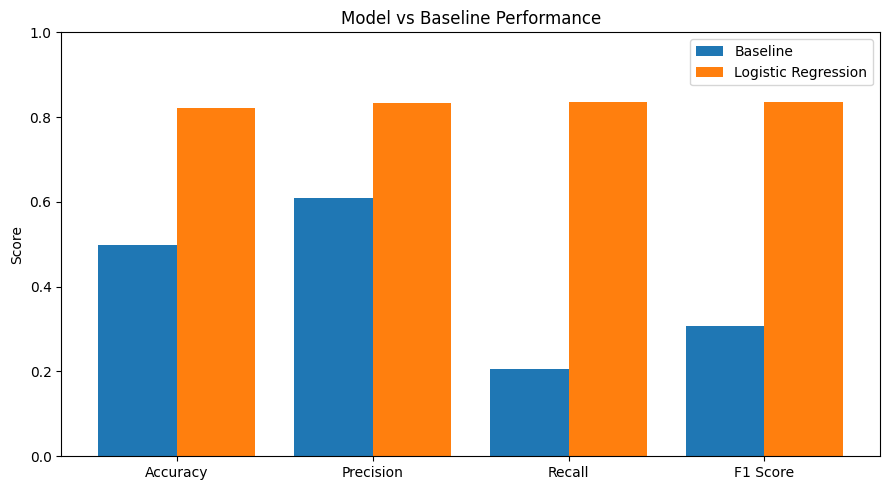

In [34]:
# Step 35 — Model vs Baseline chart

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

baseline_values = [
    baseline_accuracy,
    baseline_precision,
    baseline_recall,
    baseline_f1
]

model_values = [
    accuracy,
    precision,
    recall,
    f1
]

x = range(len(metrics))

plt.figure(figsize=(9, 5))

plt.bar(
    [i - 0.2 for i in x],
    baseline_values,
    width=0.4,
    label="Baseline"
)

plt.bar(
    [i + 0.2 for i in x],
    model_values,
    width=0.4,
    label="Logistic Regression"
)

plt.xticks(list(x), metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model vs Baseline Performance")
plt.legend()

plt.tight_layout()
plt.show()

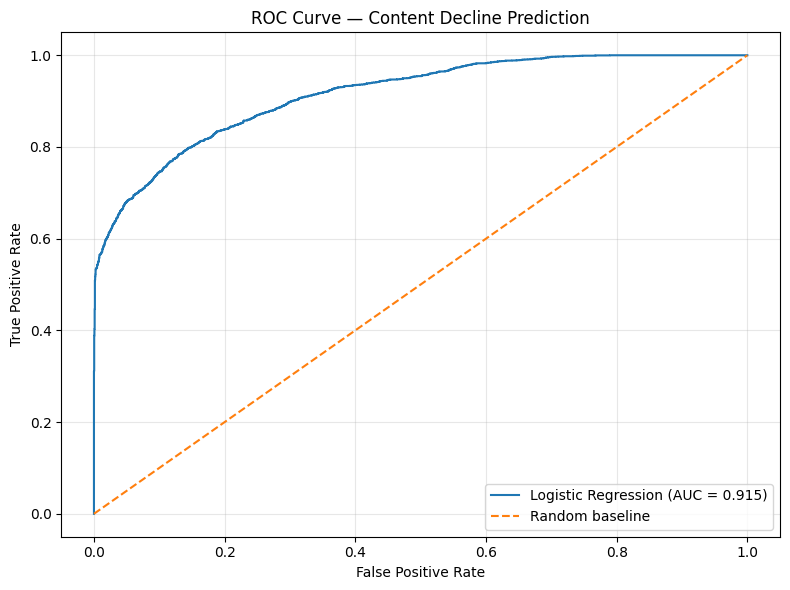

In [35]:
# Step 36 — ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_test_probability = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_probability)

# Calculate AUC
roc_auc = roc_auc_score(y_test, y_test_probability)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Content Decline Prediction")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

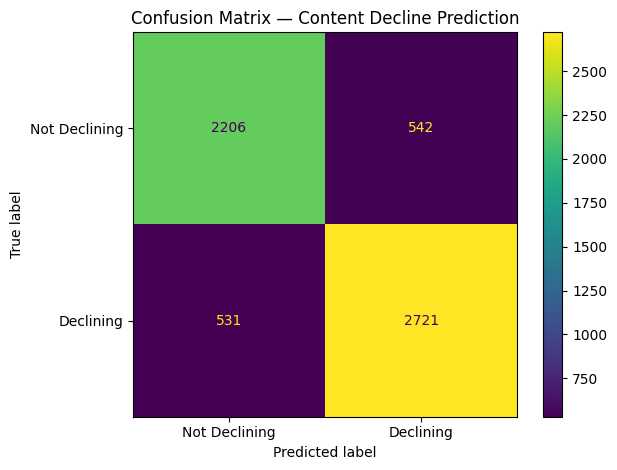

In [36]:
# Step 37 — Confusion Matrix Visualization

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Declining", "Declining"],
    values_format="d"
)

plt.title("Confusion Matrix — Content Decline Prediction")
plt.tight_layout()
plt.show()

Top 20 model features:


,feature,coefficient,absolute_coefficient
15,numeric__impressions_last_30d,-35.283368,35.283368
16,numeric__clicks_last_30d,-0.920120,0.920120
17,numeric__sessions_last_30d,-0.657775,0.657775
9,numeric__users_90d,-0.600136,0.600136
29,categorical__content_type_feedly article,-0.414783,0.414783
14,numeric__days_with_sessions,-0.406084,0.406084
33,categorical__main_intent_navigational,-0.371216,0.371216
21,numeric__content_age_days,-0.310881,0.310881
12,numeric__scroll_events_90d,-0.176104,0.176104
24,numeric__avg_position,-0.137331,0.137331


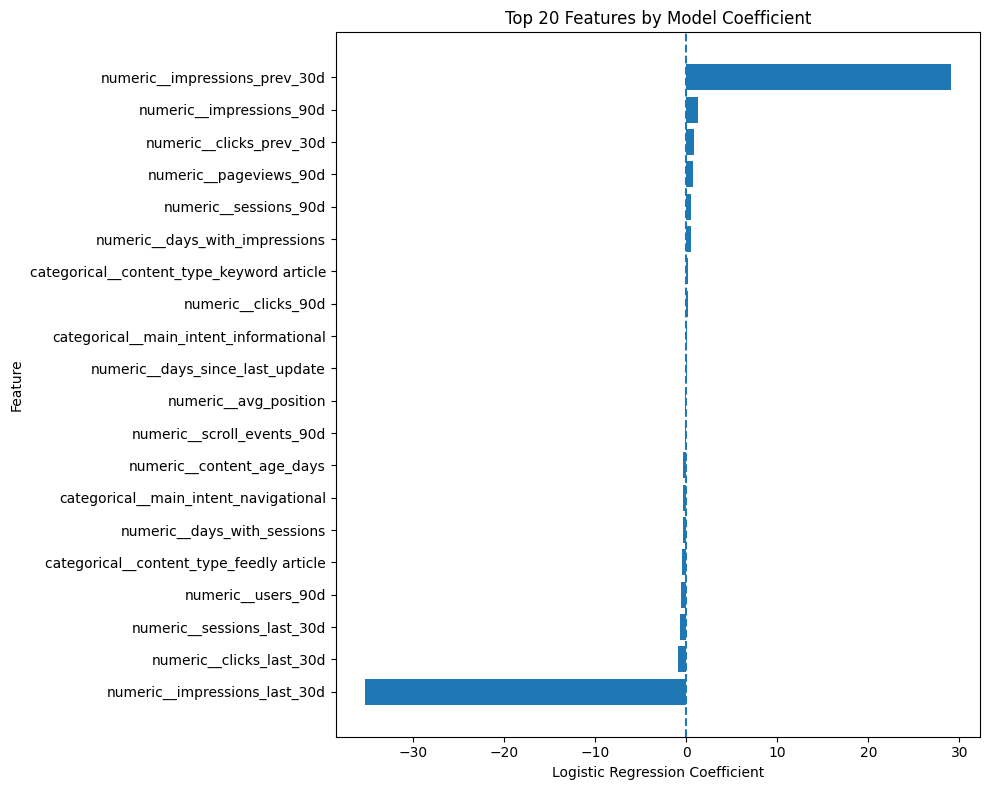

In [37]:
# Step 38 — Top feature coefficients

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["classifier"].coef_[0]

# Create feature importance table
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

feature_importance["absolute_coefficient"] = (
    feature_importance["coefficient"].abs()
)

# Select top 20
top_features = (
    feature_importance
    .sort_values("absolute_coefficient", ascending=False)
    .head(20)
    .sort_values("coefficient")
)

print("Top 20 model features:")
display(top_features)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 Features by Model Coefficient")

plt.tight_layout()
plt.show()

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
